# Troubleshooting

## Log level

Sometimes, a FESTIM model produces strange results, either because it doesn't converge or it converges "too quickly".

The first step to resolve these issues is to change the _log level_, which is the amount of information displayed by the solver.

Let's make a simple problem as an example:

In [1]:
import festim as F
import numpy as np
from dolfinx.mesh import create_unit_square
from mpi4py import MPI

my_model = F.HydrogenTransportProblem()

fenics_mesh = create_unit_square(MPI.COMM_WORLD, 10, 10)
my_model.mesh = F.Mesh(fenics_mesh)

material_top = F.Material(D_0=1, E_D=0)
material_bot = F.Material(D_0=2, E_D=0)


top_volume = F.VolumeSubdomain(id=1, material=material_top, locator=lambda x: x[1] >= 0.5)
bottom_volume = F.VolumeSubdomain(id=2, material=material_bot, locator=lambda x: x[1] <= 0.5)

top_surface = F.SurfaceSubdomain(id=1, locator=lambda x: np.isclose(x[1], 1.0))
bottom_surface = F.SurfaceSubdomain(id=2, locator=lambda x: np.isclose(x[1], 0.0))

my_model.subdomains = [top_surface, bottom_surface, top_volume, bottom_volume]

H = F.Species("H")
my_model.species = [H]

my_model.temperature = 400

my_model.boundary_conditions = [
    F.FixedConcentrationBC(subdomain=top_surface, value=1.0, species=H),
    F.FixedConcentrationBC(subdomain=bottom_surface, value=0.0, species=H),
]

my_model.exports = [
    F.TotalVolume(field=H, volume=top_volume),
    F.TotalVolume(field=H, volume=bottom_volume),
]

my_model.settings = F.Settings(atol=1e-1, rtol=1e-10, transient=True, final_time=3, stepsize=0.05)

my_model.initialise()
my_model.run()

/home/remidm/miniconda3/envs/festim-workshop/lib/python3.13/site-packages/festim/coupled_heat_hydrogen_problem.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  import tqdm.autonotebook


Solving HydrogenTransportProblem:   0%|          | 0.00/3.00 [00:00<?, ?it/s]

By default, the solver doesn't show anything but the progres bar.

Let's plot the inventory values:

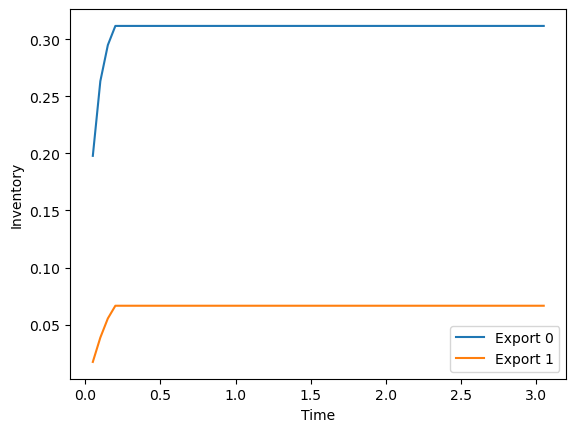

In [2]:
import matplotlib.pyplot as plt

for i, export in enumerate(my_model.exports):
    plt.plot(export.t, export.data, label=f"Export {i}")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.legend()
plt.show()

Does this look right to you? The values abruptly stop varying after a few iterations!

We can also inspect the `data` attribute of the export object:

In [3]:
my_model.exports[0].data

[0.1978318948484268,
 0.26323565775171764,
 0.2948396919548619,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.31158398221726025,
 0.311583982

To better understand what is going on, let's turn the log level to `INFO` to display more information.
We use the `dolfinx.log` module:

In [4]:
from dolfinx.log import set_log_level, LogLevel
set_log_level(LogLevel.INFO)

And run the model again:

In [5]:
my_model.initialise()
my_model.run()

[2026-02-26 16:17:55.019] [info] Checking required entities per dimension
[2026-02-26 16:17:55.019] [info] Cell type: 0 dofmap: 200x3
[2026-02-26 16:17:55.019] [info] Global index computation
[2026-02-26 16:17:55.019] [info] Got 1 index_maps
[2026-02-26 16:17:55.019] [info] Get global indices
[2026-02-26 16:17:55.019] [info] Checking required entities per dimension
[2026-02-26 16:17:55.019] [info] Cell type: 0 dofmap: 200x1
[2026-02-26 16:17:55.019] [info] Global index computation
[2026-02-26 16:17:55.019] [info] Got 1 index_maps
[2026-02-26 16:17:55.019] [info] Get global indices
[2026-02-26 16:17:55.019] [info] Checking required entities per dimension
[2026-02-26 16:17:55.019] [info] Cell type: 0 dofmap: 200x3
[2026-02-26 16:17:55.019] [info] Global index computation
[2026-02-26 16:17:55.019] [info] Got 1 index_maps
[2026-02-26 16:17:55.019] [info] Get global indices
[2026-02-26 16:17:55.032] [info] Column ghost size increased from 0 to 0


Solving HydrogenTransportProblem:   0%|          | 0.00/3.00 [00:00<?, ?it/s]

[2026-02-26 16:17:55.037] [info] SNES iter=0 ; rnorm=4.45840e+00 (atol=0.1) ; relative_residual=inf (rtol=1e-10) ; stepsize_rel=inf (stol=1.49012e-10)
[2026-02-26 16:17:55.052] [info] SNES iter=1 ; rnorm=2.06591e-15 (atol=0.1) ; relative_residual=4.63373e-16 (rtol=1e-10) ; stepsize_rel=1.00000e+00 (stol=1.49012e-10)
[2026-02-26 16:17:55.064] [info] SNES iter=0 ; rnorm=5.18958e-01 (atol=0.1) ; relative_residual=inf (rtol=1e-10) ; stepsize_rel=inf (stol=1.49012e-10)
[2026-02-26 16:17:55.070] [info] SNES iter=1 ; rnorm=1.17526e-15 (atol=0.1) ; relative_residual=2.26465e-15 (rtol=1e-10) ; stepsize_rel=1.39286e-01 (stol=1.49012e-10)
[2026-02-26 16:17:55.079] [info] SNES iter=0 ; rnorm=1.97512e-01 (atol=0.1) ; relative_residual=inf (rtol=1e-10) ; stepsize_rel=inf (stol=1.49012e-10)
[2026-02-26 16:17:55.087] [info] SNES iter=1 ; rnorm=9.10642e-16 (atol=0.1) ; relative_residual=4.61057e-15 (rtol=1e-10) ; stepsize_rel=6.96799e-02 (stol=1.49012e-10)
[2026-02-26 16:17:55.096] [info] SNES iter=0 ;

Now we see a many more things, including some `dolfinx` operations during the pre-processing, but more importantly the SNES solver monitoring.

At each timestep, we have the evolution of the different norms and residuals and their associated tolerances for each Newton iteration.


Now going back to the original problem.

At the beginning of the simulation, the solver converges in two Newton iterations.

```
[info] SNES iter=0 ; rnorm=4.45840e+00 (atol=0.1) ; relative_residual=inf (rtol=1e-10) ; stepsize_rel=inf (stol=1.49012e-10)
[info] SNES iter=1 ; rnorm=2.06591e-15 (atol=0.1) ; relative_residual=4.63373e-16 (rtol=1e-10) ; stepsize_rel=1.00000e+00 (stol=1.49012e-10)
```

```{note}
At the 0th iteration, the relative residual and relative stepsize increase are infinity.
```

And then, after a couple of timesteps, the solver starts converging in zero iteration.

```
[info] SNES iter=0 ; rnorm=6.01163e-02 (atol=0.1) ; relative_residual=inf (rtol=1e-10) ; stepsize_rel=inf (stol=1.49012e-10)
```

This happens because the residual's absolute norm `rnorm` is about `1e-2` which is already below the absolute tolerance `atol` of `0.1` (which we voluntarily set to a high value for illustration purposes).
This typically happens when the system has reached steady state. But here, the system clearly hasn't reached steady state yet.

Let's lower the absolute tolerance and run the simulation again!

In [6]:
my_model.settings.atol = 1e-10

my_model.initialise()
my_model.run()

[2026-02-26 16:17:55.551] [info] Checking required entities per dimension
[2026-02-26 16:17:55.551] [info] Cell type: 0 dofmap: 200x3
[2026-02-26 16:17:55.551] [info] Global index computation
[2026-02-26 16:17:55.551] [info] Got 1 index_maps
[2026-02-26 16:17:55.551] [info] Get global indices
[2026-02-26 16:17:55.552] [info] Checking required entities per dimension
[2026-02-26 16:17:55.552] [info] Cell type: 0 dofmap: 200x1
[2026-02-26 16:17:55.552] [info] Global index computation
[2026-02-26 16:17:55.552] [info] Got 1 index_maps
[2026-02-26 16:17:55.552] [info] Get global indices
[2026-02-26 16:17:55.552] [info] Checking required entities per dimension
[2026-02-26 16:17:55.552] [info] Cell type: 0 dofmap: 200x3
[2026-02-26 16:17:55.552] [info] Global index computation
[2026-02-26 16:17:55.552] [info] Got 1 index_maps
[2026-02-26 16:17:55.552] [info] Get global indices
[2026-02-26 16:17:55.564] [info] Column ghost size increased from 0 to 0


Solving HydrogenTransportProblem:   0%|          | 0.00/3.00 [00:00<?, ?it/s]

[2026-02-26 16:17:55.568] [info] SNES iter=0 ; rnorm=4.45840e+00 (atol=1e-10) ; relative_residual=inf (rtol=1e-10) ; stepsize_rel=inf (stol=1.49012e-10)
[2026-02-26 16:17:55.584] [info] SNES iter=1 ; rnorm=2.06591e-15 (atol=1e-10) ; relative_residual=4.63373e-16 (rtol=1e-10) ; stepsize_rel=1.00000e+00 (stol=1.49012e-10)
[2026-02-26 16:17:55.594] [info] SNES iter=0 ; rnorm=5.18958e-01 (atol=1e-10) ; relative_residual=inf (rtol=1e-10) ; stepsize_rel=inf (stol=1.49012e-10)
[2026-02-26 16:17:55.602] [info] SNES iter=1 ; rnorm=1.17526e-15 (atol=1e-10) ; relative_residual=2.26465e-15 (rtol=1e-10) ; stepsize_rel=1.39286e-01 (stol=1.49012e-10)
[2026-02-26 16:17:55.611] [info] SNES iter=0 ; rnorm=1.97512e-01 (atol=1e-10) ; relative_residual=inf (rtol=1e-10) ; stepsize_rel=inf (stol=1.49012e-10)
[2026-02-26 16:17:55.619] [info] SNES iter=1 ; rnorm=9.10642e-16 (atol=1e-10) ; relative_residual=4.61057e-15 (rtol=1e-10) ; stepsize_rel=6.96799e-02 (stol=1.49012e-10)
[2026-02-26 16:17:55.628] [info] S

Now we see that the solver converges in one iteration (as opposed to zero) for longer! Let's have a look at the derived quantities:

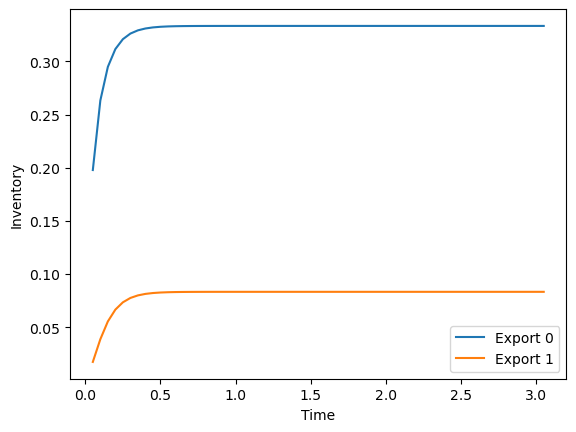

In [7]:
import matplotlib.pyplot as plt

for i, export in enumerate(my_model.exports):
    plt.plot(export.t, export.data, label=f"Export {i}")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.legend()
plt.show()

In [8]:
set_log_level(LogLevel.WARNING)

The plot is now much smoother and the (real) steady state values are different from what they were previously!

## Inspect the solution fields

Often, inspecting the solution (concentration) field is a good way to quickly identify issues.

Let's setup a 1D diffusion problem:

\begin{align}
&\frac{\partial c}{\partial t} = \nabla \cdot (D \nabla c) = D \frac{\partial^2 c}{\partial x^2} \quad \text{on  } x\in [0, 1]\\
&c = 1 \quad \text{on  } x=\{0, 1\}
\end{align}


In [120]:
my_model = F.HydrogenTransportProblem()

my_model.mesh = F.Mesh1D(vertices=np.linspace(0, 1, 11))

mat = F.Material(D_0=1, E_D=0)


vol = F.VolumeSubdomain1D(id=1, material=mat, borders=[0, 1])

left = F.SurfaceSubdomain1D(id=1, x=0)
right = F.SurfaceSubdomain1D(id=2, x=1)

my_model.subdomains = [left, right, vol]

H = F.Species("H")
my_model.species = [H]

my_model.temperature = 400

my_model.boundary_conditions = [
    F.FixedConcentrationBC(subdomain=left, value=1.0, species=H),
    F.FixedConcentrationBC(subdomain=right, value=1.0, species=H),
]

profile = F.Profile1DExport(field=H)

my_model.exports = [
    F.SurfaceFlux(field=H, surface=right),
    profile
]

my_model.settings = F.Settings(atol=1e-10, rtol=1e-10, transient=True, final_time=0.1)
my_model.settings.stepsize = F.Stepsize(initial_value=0.00001, growth_factor=1.1, cutback_factor=0.9, target_nb_iterations=4, max_stepsize=50)

my_model.initialise()
my_model.run()

Solving HydrogenTransportProblem:   0%|          | 0.00/0.10 [00:00<?, ?it/s]

This is a known mathematical problem with an analytical solution for $c$ and for the outwards flux $D \frac{\partial c}{\partial x}|_{x=1}$

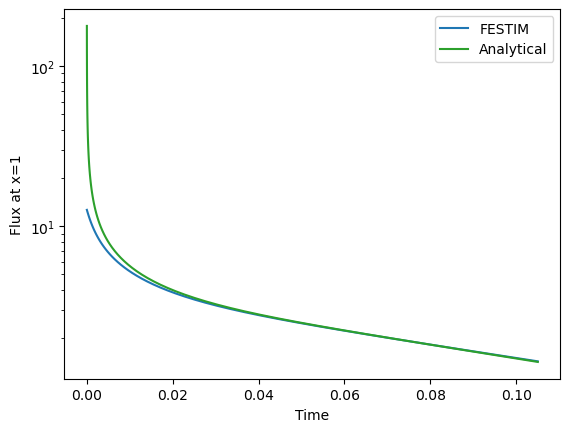

In [121]:
def analytical_solution(x, t):
    D = mat.D_0
    n = np.arange(1, 1000)[:, np.newaxis]
    A_n = 4 / ((2 * n - 1) * np.pi)
    return 1 - np.sum(
        A_n * np.sin((2*n - 1) * np.pi * x) * np.exp(-D * ((2*n - 1) * np.pi) ** 2 * t),
        axis=0
    )

def analytical_solution_flux_right(t):
    D = mat.D_0
    n = np.arange(1, 1000)[:, np.newaxis]
    A_n = 4 / ((2 * n - 1) * np.pi)
    return np.sum(
        A_n * (2*n - 1) * np.pi * D * np.exp(-D * ((2*n - 1) * np.pi) ** 2 * t),
            axis=0
    )

plt.plot(my_model.exports[0].t, -np.array(my_model.exports[0].data), label="FESTIM")
plt.plot(my_model.exports[0].t, analytical_solution_flux_right(my_model.exports[0].t), label="Analytical", color="tab:green")
plt.xlabel("Time")
plt.ylabel("Flux at x=1")
plt.yscale("log")
plt.legend()
plt.show()

The agreement with the analytical solution at small $t$ is really off. What's the issue?

Let's plot the concentration profile!

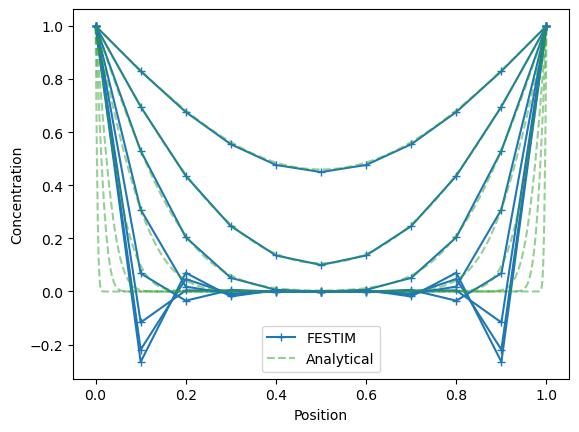

In [122]:
spacing = 10
data = profile.data[::spacing]
times = profile.t[::spacing]

x_analytical = np.linspace(0, 1, 1000)

for t, c in zip(times, data):
    l_festim, = plt.plot(profile.x, c, marker="+", color="tab:blue")
    l_analytical, =plt.plot(x_analytical, analytical_solution(x_analytical, t), color="tab:green", linestyle="dashed", alpha=0.5)
plt.xlabel("Position")
plt.ylabel("Concentration")
plt.legend([l_festim, l_analytical], ["FESTIM", "Analytical"])
plt.show()

In [123]:
# delete some objects to reset the model and profile, see issue https://github.com/festim-dev/FESTIM/issues/1079
my_model.volume_meshtags = None
my_model.facet_meshtags = None
my_model.bc_forms = []
profile.data = []
profile.t = []
profile.x = None
profile._dofs = None
profile._sort_coords = None

There we go: at small times, the concentration gradient is very to big to be approximated properly by the numerical solution on this mesh.

In other words, the mesh is not refined enough. Let's crank it up!

In [124]:
my_model.mesh = F.Mesh1D(vertices=np.linspace(0, 1, 1000))

my_model.initialise()
my_model.run()

Solving HydrogenTransportProblem:   0%|          | 0.00/0.10 [00:00<?, ?it/s]

Now the FESTIM solution is much closer to the analytical solution at small timesteps!

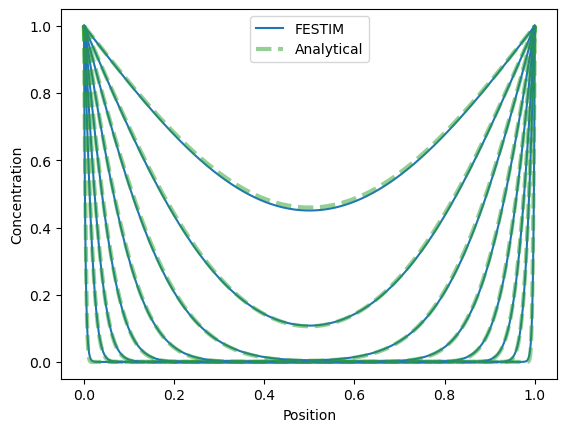

In [125]:
spacing = 10
data = profile.data[::spacing]
times = profile.t[::spacing]

x_analytical = np.linspace(0, 1, 1000)

for t, c in zip(times, data):
    l_festim, = plt.plot(profile.x, c, color="tab:blue")
    l_analytical, =plt.plot(x_analytical, analytical_solution(x_analytical, t), color="tab:green", linestyle="dashed", alpha=0.5, linewidth=3)
plt.xlabel("Position")
plt.ylabel("Concentration")
plt.legend([l_festim, l_analytical], ["FESTIM", "Analytical"])
plt.show()

Wich, in turn, fixes the flux mismatch!

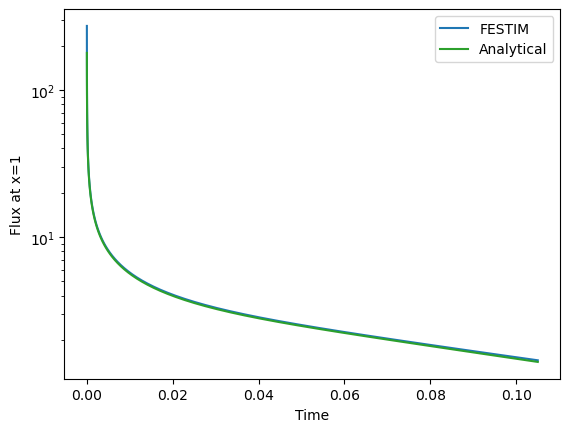

In [126]:
plt.plot(my_model.exports[0].t, -np.array(my_model.exports[0].data), label="FESTIM")
plt.plot(my_model.exports[0].t, analytical_solution_flux_right(my_model.exports[0].t), label="Analytical", color="tab:green")
plt.xlabel("Time")
plt.ylabel("Flux at x=1")
plt.yscale("log")
plt.legend()
plt.show()

`````{admonition} Global vs Local refinement
:class: tip

Here the refinement was overkill. We refined the mesh _globally_.

We could have been more efficient and perform a local refinement in the high gradient regions.


```{code-cell} ipython3
x1 = 0.05
x2 = 0.95
vertices = np.concatenate(
    [
        np.linspace(0, x1, 100),  # refine the mesh near x=0
        np.linspace(x1, x2, 100),  # keep the same mesh in the middle
        np.linspace(x2, 1, 100)  # refine the mesh near x=1
    ]
)

my_model.mesh = F.Mesh1D(vertices)
```

`````

## Penalty term for interfaces

Soon